# 🏠 House Prices Prediction

## Advanced Regression Techniques - Kaggle Competition

An end-to-end machine learning project focused on predicting house sale prices through data exploration, preprocessing, feature engineering, and regression modeling.


## 📑 Notebook Contents

- [📥 Load the Dataset](#-load-the-dataset)
- [🛠️ Handle Missing Values](#-handle-missing-values)
- [🛠️ Handle Categorical Features](#-handle-categorical-features)
- [🤖 Model Training & Evaluation](#-Prediciton-and-Selecting-the-Algorithm)
- [🧠 Neural Network](#-artificial-neural-network-implementation)


## Load the Dataset

In [ ]:
# Import libraries

import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler


import xgboost as xgb

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

from tensorflow.keras.callbacks import CSVLogger

from tensorflow.keras import backend as K

In [112]:
df = pd.read_csv('data/train.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [113]:
df['MSZoning'].value_counts()

MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

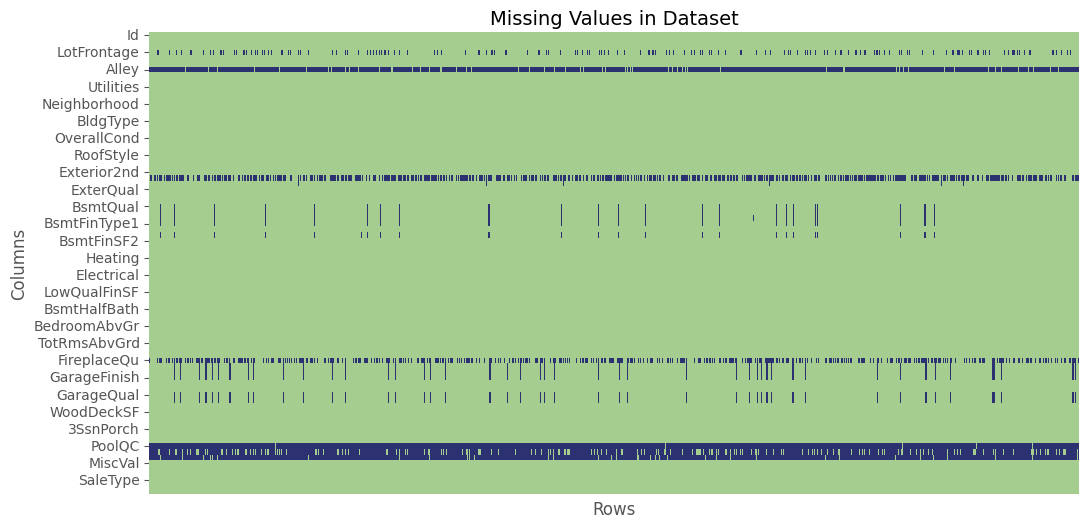

(1460, 81)

In [114]:
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull().T,
    xticklabels=False,
    cbar=False,
    cmap='crest'
)

plt.title('Missing Values in Dataset', fontsize=14)
plt.xlabel('Rows')
plt.ylabel('Columns')

plt.savefig(
    "images/missing_values_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

df.shape

In [115]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

## Filling Missing Values

In [116]:
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [117]:
df['BsmtCond']=df['BsmtCond'].fillna(df['BsmtCond'].mode()[0])
df['BsmtQual']=df['BsmtQual'].fillna(df['BsmtQual'].mode()[0])

In [118]:
df['FireplaceQu']=df['FireplaceQu'].fillna(df['FireplaceQu'].mode()[0])
df['GarageType']=df['GarageType'].fillna(df['GarageType'].mode()[0])

In [119]:
df['GarageFinish']=df['GarageFinish'].fillna(df['GarageFinish'].mode()[0])
df['GarageQual']=df['GarageQual'].fillna(df['GarageQual'].mode()[0])
df['GarageCond']=df['GarageCond'].fillna(df['GarageCond'].mode()[0])

In [120]:
df['MasVnrType']=df['MasVnrType'].fillna(df['MasVnrType'].mode()[0])
df['MasVnrArea']=df['MasVnrArea'].fillna(df['MasVnrArea'].mode()[0])

In [121]:
df['BsmtExposure']=df['BsmtExposure'].fillna(df['BsmtExposure'].mode()[0])

In [122]:
df['BsmtFinType2']=df['BsmtFinType2'].fillna(df['BsmtFinType2'].mode()[0])

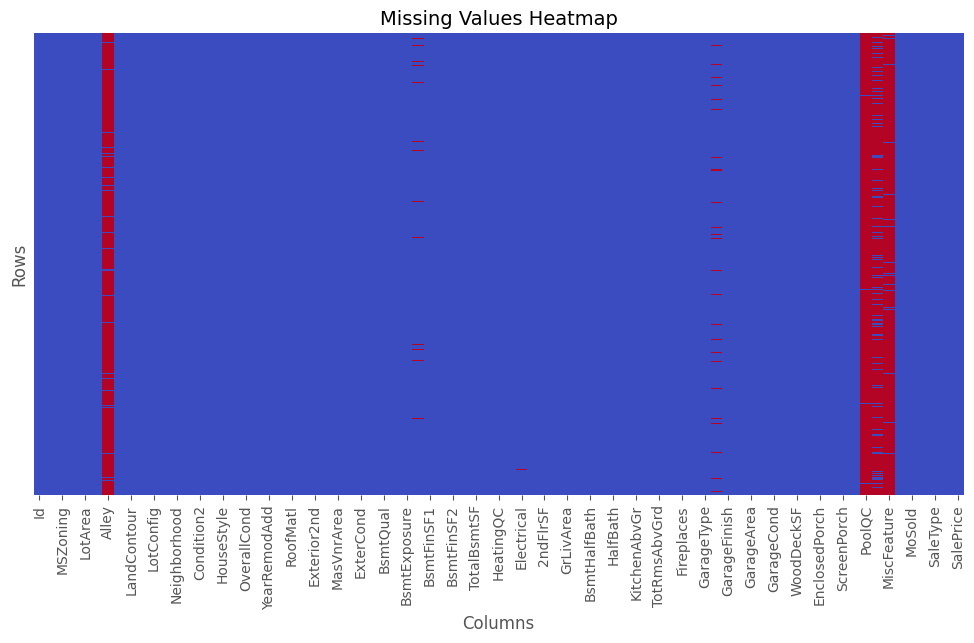

In [123]:
# Create images folder if it doesn't exist
os.makedirs("images", exist_ok=True)

plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap="coolwarm"
)

plt.title("Missing Values Heatmap", fontsize=14)
plt.xlabel("Columns")
plt.ylabel("Rows")

# Save the figure
plt.savefig(
    "images/missing_values_heatmap_rows.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [124]:
df.shape

(1460, 81)

In [125]:
df.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 81, dtype: int64

In [126]:
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


## Handle Categorical Features

In [127]:
columns = [
    'MSSubClass','MSZoning','Street','Alley','LotShape','LandContour',
    'LotConfig','LandSlope','Neighborhood','Condition1','Condition2',
    'BldgType','HouseStyle','RoofStyle','RoofMatl','Exterior1st',
    'Exterior2nd','MasVnrType','ExterQual','ExterCond','Foundation',
    'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
    'Heating','HeatingQC','CentralAir','Electrical','KitchenQual',
    'Functional','FireplaceQu','GarageType','GarageFinish',
    'GarageQual','GarageCond','PavedDrive','PoolQC','Fence',
    'SaleType','SaleCondition'
]
len(columns)

42

In [128]:
def category_onehot_multcols(df, columns):
    """
    Apply One-Hot Encoding to multiple categorical columns.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        columns (list): List of categorical columns.

    Returns:
        pd.DataFrame: Encoded DataFrame.
    """
    return pd.get_dummies(
        df,
        columns=columns,
        drop_first=True,
        dtype=int
    )

In [129]:
main_df = df.copy()

In [130]:
test_df=pd.read_csv('data/test.csv')
test_df.shape

(1459, 80)

In [131]:
test_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [132]:
final_df = pd.concat([df,test_df],axis=0)

In [133]:
df.drop(['MiscVal','Id','MiscFeature','Utilities'],axis=1,inplace=True)
final_df.drop(['MiscVal','Id','MiscFeature','Utilities'],axis=1,inplace=True)

In [134]:
print(final_df.shape)
final_df['SalePrice']

(2919, 77)


0       208500.0
1       181500.0
2       223500.0
3       140000.0
4       250000.0
          ...   
1454         NaN
1455         NaN
1456         NaN
1457         NaN
1458         NaN
Name: SalePrice, Length: 2919, dtype: float64

In [135]:
# Fill remaining NaNs across the combined set
for col in final_df.select_dtypes(include='object').columns:
    final_df[col] = final_df[col].fillna(final_df[col].mode()[0])
for col in final_df.select_dtypes(include=['int64','float64']).columns:
    if col != 'SalePrice':  # don't touch the target
        final_df[col] = final_df[col].fillna(final_df[col].median())

In [136]:
final_df = category_onehot_multcols(final_df, columns)
final_df.shape

(2919, 254)

In [137]:
final_df = final_df.loc[:,~final_df.columns.duplicated()]
final_df.shape

(2919, 254)

In [138]:
final_df

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,150.0,...,0,0,0,0,1,0,0,0,1,0
1,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,284.0,...,0,0,0,0,1,0,0,0,1,0
2,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,434.0,...,0,0,0,0,1,0,0,0,1,0
3,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,540.0,...,0,0,0,0,1,0,0,0,0,0
4,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,490.0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,21.0,1936,4,7,1970,1970,0.0,0.0,0.0,546.0,...,0,0,0,0,1,0,0,0,1,0
1455,21.0,1894,4,5,1970,1970,0.0,252.0,0.0,294.0,...,0,0,0,0,1,0,0,0,0,0
1456,160.0,20000,5,7,1960,1996,0.0,1224.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
1457,62.0,10441,5,5,1992,1992,0.0,337.0,0.0,575.0,...,0,0,0,0,1,0,0,0,1,0


In [139]:
df_Train = final_df.iloc[:1460, :]
df_Test  = final_df.iloc[1460:, :]

df_Train = df_Train[df_Train['GrLivArea'] <= 4000]

In [140]:
df_Train.head()


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,150.0,...,0,0,0,0,1,0,0,0,1,0
1,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,284.0,...,0,0,0,0,1,0,0,0,1,0
2,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,434.0,...,0,0,0,0,1,0,0,0,1,0
3,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,540.0,...,0,0,0,0,1,0,0,0,0,0
4,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,490.0,...,0,0,0,0,1,0,0,0,1,0


In [141]:
df_Test.head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,0,0,0,0,1,0,0,0,1,0
1,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,0,0,0,0,1,0,0,0,1,0
2,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,0,0,0,0,1,0,0,0,1,0
3,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,324.0,...,0,0,0,0,1,0,0,0,1,0
4,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,1017.0,...,0,0,0,0,1,0,0,0,1,0


In [142]:
df_Train.shape

(1456, 254)

In [143]:
df_Test.drop(['SalePrice'],axis=1,inplace=True)
X_train=df_Train.drop(['SalePrice'],axis=1)
y_train=df_Train['SalePrice']


C:\Users\NOTEBOOK\AppData\Local\Temp\ipykernel_8020\2814958886.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Test.drop(['SalePrice'],axis=1,inplace=True)


## Prediciton and Selecting the Algorithm

In [144]:
classifier = xgb.XGBRegressor()
regressor = xgb.XGBRegressor()

In [145]:
booster = ['gbtree', 'gblinear']
base_score = [0.3, 0.5, 0.7]

In [146]:
hyperparameter_grid = {
    'n_estimators': [100, 300, 500, 800],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1, 0.3]
}

In [147]:
random_cv = RandomizedSearchCV(
    estimator=regressor,
    param_distributions=hyperparameter_grid,
    cv=5,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    n_jobs=4,
    verbose=5,
    return_train_score=True,
    random_state=42
)

In [148]:
model = xgb.XGBRegressor(tree_method='hist')

In [149]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [150]:
random_cv.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBRegressor(...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.8, 1.0], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters 

In [151]:
X_train.select_dtypes(include='object').columns

Index([], dtype='object')

In [152]:
print("Best CV score (neg MAE):", random_cv.best_score_)

random_cv.best_estimator_

Best CV score (neg MAE): -14559.697210772374


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,1.0
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [153]:
regressor = xgb.XGBRegressor(
    base_score=0.25,
    booster='gbtree',
    learning_rate=0.1,
    max_depth=2,
    min_child_weight=1,
    n_estimators=900,
    objective='reg:squarederror',
    random_state=0
)

In [154]:
y_train_log = np.log1p(y_train)
regressor.fit(X_train, y_train_log)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.25
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
m_file = 'model/finalized_model.pkl'

with open(m_file, 'wb') as f:
    pickle.dump(regressor, f)

In [156]:
if 'SalePrice' in df_Test.columns:
    df_Test = df_Test.drop(['SalePrice'], axis=1)

In [157]:
print(df_Test.shape)
df_Test.head()

(1459, 253)


,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,80.0,11622,5,6,1961,1961,0.0,468.0,144.0,270.0,...,0,0,0,0,1,0,0,0,1,0
1,81.0,14267,6,6,1958,1958,108.0,923.0,0.0,406.0,...,0,0,0,0,1,0,0,0,1,0
2,74.0,13830,5,5,1997,1998,0.0,791.0,0.0,137.0,...,0,0,0,0,1,0,0,0,1,0
3,78.0,9978,6,6,1998,1998,20.0,602.0,0.0,324.0,...,0,0,0,0,1,0,0,0,1,0
4,43.0,5005,8,5,1992,1992,0.0,263.0,0.0,1017.0,...,0,0,0,0,1,0,0,0,1,0


In [158]:
print(df_Test.shape)
print('SalePrice' in df_Test.columns)  # should be False

(1459, 253)
False


In [159]:
y_pred = np.expm1(regressor.predict(df_Test))
y_pred

array([116080.89, 156965.86, 187281.28, ..., 156191.6 , 117863.61,
       222629.06], shape=(1459,), dtype=float32)

In [160]:
pred = pd.DataFrame(y_pred, columns=['SalePrice'])
sub_df = pd.read_csv('data/sample_submission.csv')  # keep the original untouched
datasets = pd.concat([sub_df['Id'], pred], axis=1)
datasets.to_csv('data/sample_submission.csv', index=False)  # write to a NEW file

## Artificial Neural Network Implementation

In [161]:

# RMSE Loss Function
def root_mean_squared_error(y_true, y_pred):
    return K.sqrt(K.mean(K.square(y_pred - y_true)))

In [162]:
os.makedirs("outputs", exist_ok=True)  # ensure folder exists before logging

In [163]:
classifier = Sequential()

classifier.add(Dense(
    units=50,
    kernel_initializer='he_uniform',
    activation='relu',
    input_dim=X_train.shape[1]
))

classifier.add(Dense(
    units=25,
    kernel_initializer='he_uniform',
    activation='relu'
))

classifier.add(Dense(
    units=50,
    kernel_initializer='he_uniform',
    activation='relu'
))

classifier.add(Dense(
    units=1,
    kernel_initializer='he_uniform'
))

classifier.compile(
    optimizer='Adamax',
    loss = root_mean_squared_error
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
df_Test_scaled = scaler.transform(df_Test)

history = classifier.fit (
    X_train.values,
    y_train.values,
    validation_split=0.2,
    batch_size=10,
    epochs=1000,
    callbacks=[CSVLogger("outputs/training_log.csv")]
)

Epoch 1/1000


c:\Users\NOTEBOOK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 181390.6094 - val_loss: 155927.0312
Epoch 2/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 103426.2578 - val_loss: 59948.1250
Epoch 3/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 65051.4102 - val_loss: 57516.1250
Epoch 4/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62732.5352 - val_loss: 56046.7070
Epoch 5/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 60771.9570 - val_loss: 54443.3203
Epoch 6/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 58288.4180 - val_loss: 53083.1641
Epoch 7/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 56098.7578 - val_loss: 51661.7812
Epoch 8/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 54868.9570 - val_loss: 50723.9570
Epoch 9/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53024.3320 - val_loss: 49253.9805
Epoch 10/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 50653.4766 - val_loss: 47571.6133
Epoch 11/1000
117/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms

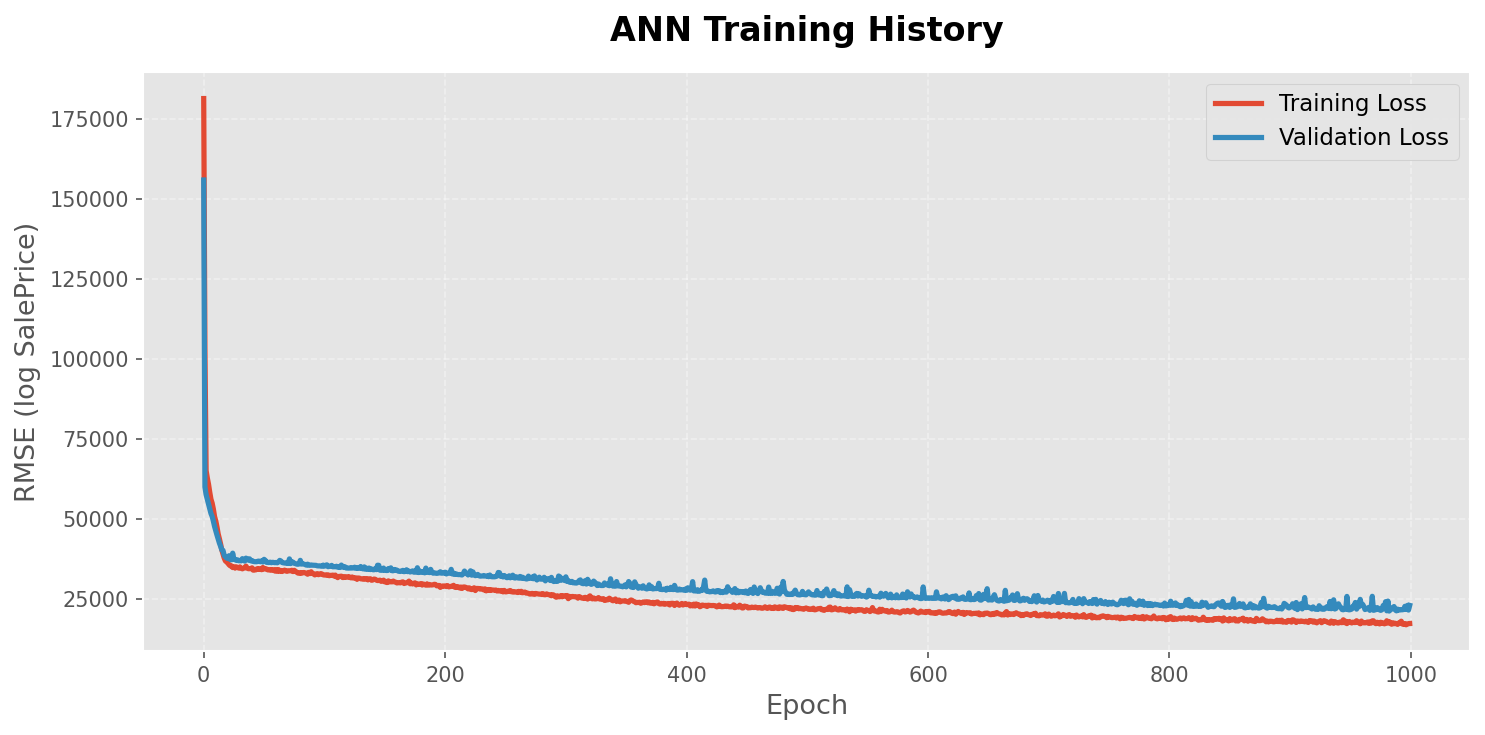

In [164]:

log = pd.read_csv("outputs/training_log.csv")

plt.style.use("ggplot")
plt.figure(figsize=(10, 5), dpi=150)

plt.plot(log["loss"], label="Training Loss", linewidth=2.5)
plt.plot(log["val_loss"], label="Validation Loss", linewidth=2.5)

plt.title("ANN Training History", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Epoch", fontsize=13)
plt.ylabel("RMSE (log SalePrice)", fontsize=13)
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()

plt.savefig("images/ann_training_curve.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [165]:
ann_pred = classifier.predict(df_Test.values)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
